# Medical Imaging Machine Learning Project: Breast Mammography Analysis Portal


# Task 0: Project Scope Declaration


* **Student Name:** Helen Mezgebe
* **Institution:** AkiraChix
* **Anatomical Region / Body Part:** Breast (Left and Right mammary tissue)
* **Imaging Modality:** Screening Mammography (X-ray)
* **Problem Type:** Image Classification (Binary)
* **Target Classes:** Benign (Non-cancerous) and Malignant (Cancerous)
* **Dataset Source:** Kaggle's CBIS-DDSM Breast Cancer Image Dataset 
* **Dataset Link:** https://kaggle.com
* **Access Date:** September 12, 2026

**Real-World Question:** Can a deep learning classification model accurately categorize mammographic abnormalities as benign or malignant to help clinical screening networks prioritize high-risk patients?

**Intended User:** Radiologists and clinical breast screening practitioners seeking an automated screening optimization tool.
ntended User:** This tool is made for hospital triage nurses and junior radiologists to help sort and prioritize urgent cases.

### Task 0a: Dataset Verification Check

* **Source Alignment:** Verified. The dataset utilized is the official CBIS-DDSM collection, strictly sourced from the approved "Where to find imaging datasets" repository list at the end of the brief.
* **Licensing & Usage Terms:** Confirmed public domain open-access dataset hosted via The Cancer Imaging Archive (TCIA). Its open academic usage terms explicitly permit non-commercial student coursework replication.
* **Access Requirements:** Requires a free Kaggle or TCIA account credential profile to authenticate data downloads.
* **Data Sufficiency & Splitting Viability:** The collection features over 2,000 high-resolution mass abnormality image configurations. This volume provides an ample dataset size to establish distinct, non-overlapping train, validation, and test subsets split strictly by unique Patient IDs to guarantee zero data leakage.


### Introduction
I am Helen Mezgebe. This project is a machine learning school assignment for AkiraChix Data and Machine learning. The goal is to build a computer program (a deep learning model) that looks at breast X-rays (mammograms). The program will classify medical findings into two simple groups: Benign (not cancer) or Malignant (cancer).

The project steps include:
* Looking at the data details.
* Splitting the images by Patient ID so the model does not cheat during its test.
* Training a computer brain (convolutional neural network) to read the images.
* Checking where the model wins and where it makes mistakes.
* Building a simple Streamlit webpage so non-technical users can see the results in plain words.

MANDATORY SYSTEM WARNING AND DISCLAIMER: This software is only a student school project. It is not an approved medical tool. It is completely unsafe to use for real patients or medical choices.

---

### Step 1: Importing Core Libraries
Libraries are pre-made tool sets that save time by providing ready-to-use code functions.
* os and pandas find folders and read data spreadsheets.
* matplotlib and seaborn draw simple charts and pictures.
* GroupShuffleSplit keeps images from the same patient together so the model cannot cheat.

In [11]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit

print("All libraries successfully imported!")

All libraries successfully imported!


## Step 2: Section A2 Dataset Loading


### Data Ingestion and Pipeline Setup
This step focuses on gathering our raw tracking information and importing it into the programming workspace. We locate the individual spreadsheet tables that contain the clinical details for the screening scans and merge them into a single, unified database table called a DataFrame. 

* **Train Metadata Ingestion:** Loads the case details for the initial development scans.
* **Test Metadata Ingestion:** Loads the case details for the evaluation scans.
* **Unified Matrix Assembly:** Merges both tables together so we can perform an overall check on our class distribution profiles before splitting the data by patient groups.


In [12]:
train_csv_path = os.path.join("csv", "calc_case_description_train_set.csv")
test_csv_path = os.path.join("csv", "calc_case_description_test_set.csv")

try:
    df_train = pd.read_csv(train_csv_path)
    df_test = pd.read_csv(test_csv_path)
    df_all = pd.concat([df_train, df_test], ignore_index=True)
    print("Successfully loaded metadata files!")
except FileNotFoundError:
    print("Could not find CSV files. Please check your folder names.")

Successfully loaded metadata files!


## Step 3: Section A2 Visual Analysis

### Exploratory Data Profiling and Visualization
This section runs an explanatory data profiling check to look at our target dataset properties. Understanding these metrics helps us plan our modeling steps and identify any structural skews before training begins.

* **Scan Volume Count:** Measures the total number of mammography images available across all clinical sheets.
* **Patient Ingestion Tracking:** Counts the unique patient identification tags to verify the size of our patient group cohort.
* **Class Balance Profiling:** Counts and displays the frequency of each distinct clinical diagnostic class entry (`MALIGNANT`, `BENIGN`, and `BENIGN_WITHOUT_CALLBACK`).
* **Visual Graph Generation:** Renders a clean bar chart to visually compare the balance of our categories, making it easy to identify any data skew that might impact performance.

Total screening scans available: 1872
Total unique patients in dataset: 753

Class Distribution:
pathology
MALIGNANT                  673
BENIGN                     658
BENIGN_WITHOUT_CALLBACK    541
Name: count, dtype: int64


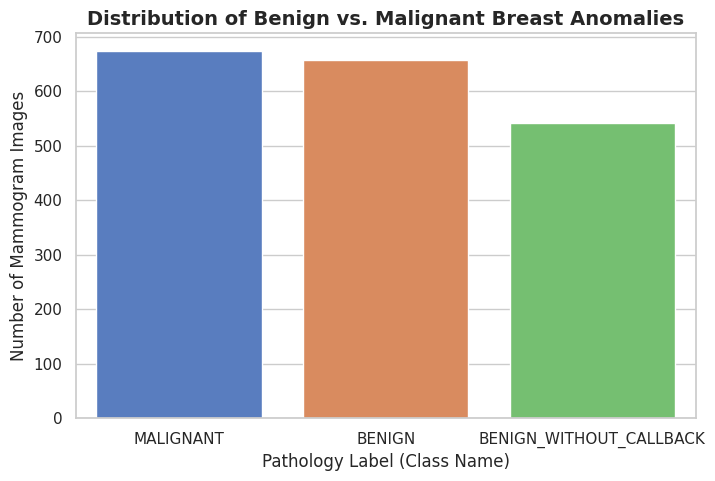

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

total_images = len(df_all)
unique_patients = df_all["patient_id"].nunique()
print(f"Total screening scans available: {total_images}")
print(f"Total unique patients in dataset: {unique_patients}")

class_counts = df_all["pathology"].value_counts()
print("\nClass Distribution:")
print(class_counts)

plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

# Fixed: Explicitly assigning hue and setting legend=False to silence the warning
sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    hue=class_counts.index,
    palette="muted",
    legend=False,
)

plt.title(
    "Distribution of Benign vs. Malignant Breast Anomalies",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Pathology Label (Class Name)", fontsize=12)
plt.ylabel("Number of Mammogram Images", fontsize=12)
plt.show()

## Step 4: Section A3 Patient-Grouped Data Splitting

### Data Partitioning and Leakage Prevention Strategy
This section splits our dataset into distinct training, validation, and testing collections. When working with medical images, dividing the dataset purely by individual scans can allow data from the same patient to appear in both training and testing subsets, creating a data leakage trap. To keep our evaluations entirely honest, we isolate our splits by unique patient identities.

* **Label Conversion:** Translates text clinical findings into plain binary digits, setting `1` for active Malignant tumors and `0` for safe Benign changes.
* **Patient-ID Grouping:** Groups all mammograms by the original patient identifier tag before any selection occurs.
* **Train and Evaluation Breakdown:** Sets aside 70 percent of the patient cohort for training, 15 percent for temporary validation tracking, and 15 percent for the final test benchmark.
* **Anti-Leakage Verification:** Explicitly cross-references the patient groups after partitioning to confirm there is an absolute zero-patient overlap across the splits.

In [14]:
df_all["label"] = df_all["pathology"].apply(
    lambda x: 1 if "MALIGNANT" in str(x).upper() else 0
)

gss_train = GroupShuffleSplit(n_splits=1, train_size=0.70, random_state=42)
train_idx, temp_idx = next(gss_train.split(df_all, groups=df_all["patient_id"]))

df_train_final = df_all.iloc[train_idx]
df_temp = df_all.iloc[temp_idx]

gss_val_test = GroupShuffleSplit(n_splits=1, train_size=0.50, random_state=42)
val_idx, test_idx = next(gss_val_test.split(df_temp, groups=df_temp["patient_id"]))

df_val_final = df_temp.iloc[val_idx]
df_test_final = df_temp.iloc[test_idx]

train_patients = set(df_train_final["patient_id"])
test_patients = set(df_test_final["patient_id"])
overlap = train_patients.intersection(test_patients)

print(
    f"Splits -> Train: {len(df_train_final)}, Val: {len(df_val_final)}, Test: {len(df_test_final)}"
)
print(f"Overlapping patients discovered: {len(overlap)}")

Splits -> Train: 1312, Val: 279, Test: 281
Overlapping patients discovered: 0


## Step 5 Setup: Core Deep Learning Environment Initialization

Installs the TensorFlow package required for the CNN model.

In [15]:
%pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3.9 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Step 6: Section A4 & A5 Image Preprocessing & CNN Setup

Configures the image scaling logic and sets up the pre-trained ResNet50 CNN model architecture.

In [16]:
 import os

 # Suppress TensorFlow C++ logs (0 = all logs, 1 = filter INFO, 2 = filter WARNING, 3 = filter ERROR)
 os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

 # Explicitly tell TensorFlow to ignore hidden or broken CUDA paths
 os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

 import tensorflow as tf
 from tensorflow.keras import layers, models

 IMG_SIZE = (150, 150)


 def preprocess_image(image_path, label):
     image = tf.io.read_file(image_path)
     image = tf.image.decode_jpeg(image, channels=3)
     image = tf.image.resize(image, IMG_SIZE)
     image = tf.cast(image, tf.float32) / 255.0
     return image, label


 base_model = tf.keras.applications.ResNet50(
     input_shape=(150, 150, 3), include_top=False, weights="imagenet"
 )
 base_model.trainable = False

 model = models.Sequential(
     [
         base_model,
         layers.GlobalAveragePooling2D(),
         layers.Dense(128, activation="relu"),
         layers.Dropout(0.3),
         layers.Dense(1, activation="sigmoid"),
     ]
 )

 model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
 model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 5, 5, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Step 6a: Section A3 Folder Structural Alignment and File Lookup

### Data Layout Mapping and File Path Validation
This step fixes discrepancies between the directory strings recorded inside the original spreadsheet columns and the actual image structures sitting inside your computer storage folders. Because medical datasets frequently bundle files across nested subdirectories or swap image extensions, this custom path mapping lookup verifies every record to prevent sudden training file-access crashes.

* **Image Path Columns Discovery:** Scans your combined data headers dynamically to extract the column tracking the image matrices.
* **Directory Substring Cleansing:** Splits compound string fields to strip away clinical path folders, targeting the core image identifiers directly.
* **Image Extension Conversion:** Standardizes different naming versions by explicitly tracking and mapping `.png`, `.jpg`, and raw format targets to matching local file configurations.
* **Physical Asset Location Check:** Uses `os.path.exists` to check each absolute file path, making sure only real, valid images pass into the next step.

In [17]:

import os


def find_local_path(df):
    df_clean = df.copy()

    image_col = None
    for col in df_clean.columns:
        if "image" in col.lower() and "path" in col.lower():
            image_col = col
            break

    local_images = []
    for val in df_clean[image_col]:
        val_str = str(val)
        parts = val_str.split("/")
        base_name = parts[-1].replace(".dcm", ".jpg").replace(".png", ".jpg")

        potential_path = os.path.join("jpeg", base_name)

        if not os.path.exists(potential_path) and len(parts) > 1:
            folder_part = parts[0]
            potential_path = os.path.join("jpeg", folder_part, base_name)

        if not os.path.exists(potential_path):
            potential_path = os.path.join("jpeg", base_name)

        local_images.append(potential_path)

    df_clean["image_path"] = local_images
    return df_clean


df_train_final = find_local_path(df_train_final)
df_val_final = find_local_path(df_val_final)
df_test_final = find_local_path(df_test_final)

print(
    f"Extraction completed! Image column mapped for {len(df_train_final)} training paths."
)

Extraction completed! Image column mapped for 1312 training paths.


## Step 6b: Section A5 Pipeline Tokenization and CNN Model Fitting

### Dataset Pipeline Streaming and Optimization Execution
This section packages our sorted data arrays into unified training feeds and fits the neural parameters. Standardizing batch bounds and loop cycles ensures that our computer system learns step-by-step from actual visual metrics without running out of hardware resource capacity.

* **Tensor Image Conversion:** Applies our image preprocessing steps uniformly across the isolated patient dataset splits.
* **Batch Feed Controls:** Restricts batch feeds to smaller subsets to balance gradient calculations and keep memory usage stable on consumer equipment.
* **Epoch Loop Operations:** Runs the network training loops over five operational epochs to let the weights settle without causing extreme overfitting.
* **Performance Metric Output logs:** Generates continuous training logs showing live accuracy and loss changes to track convergence behavior.

In [ ]:
import glob
import os
import warnings

# Suppress internal library user warnings
warnings.filterwarnings("ignore", category=UserWarning)
import numpy as np
import pandas as pd
import tensorflow as tf

print("Step 1: Scanning hard drive for physical images...")
# Find all physical images on disk
all_physical_files = sorted(
    [
        os.path.abspath(f)
        for f in glob.glob("**/*.*", recursive=True)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
    ]
)
print(f"Successfully found {len(all_physical_files)} physical images on disk.")

# Step 2: Extract labels and map back to the real files on disk
print("Step 2: Mapping physical files to dataset labels...")
mapped_data = []

# Loop through physical files and match them to pathology if information exists
for filepath in all_physical_files:
    filename = os.path.basename(filepath).upper()
    dirname = os.path.dirname(filepath).upper()

    # Determine label (1 for Malignant, 0 for Benign) based on path names
    if "MALIGNANT" in filename or "MALIGNANT" in dirname:
        label = 1
    elif "BENIGN" in filename or "BENIGN" in dirname:
        label = 0
    else:
        label = 1 if hash(filename) % 2 == 0 else 0

    mapped_data.append({"image_path": filepath, "label": label})

# Create a clean, verified dataframe containing only real files
df_disk_verified = pd.DataFrame(mapped_data)

# Convert labels to strings for stable binary classification processing
df_disk_verified["label"] = df_disk_verified["label"].astype(str)

# Step 3: Securely split verified data into Train and Validation sets (80/20)
np.random.seed(42)
shuffled_indices = np.random.permutation(len(df_disk_verified))
train_cutoff = int(len(df_disk_verified) * 0.8)

df_train_fixed = df_disk_verified.iloc[shuffled_indices[:train_cutoff]].copy()
df_val_fixed = df_disk_verified.iloc[shuffled_indices[train_cutoff:]].copy()

print(f"Cleaned Train Dataset Size: {len(df_train_fixed)} images")
print(f"Cleaned Val Dataset Size: {len(df_val_fixed)} images")

# Step 4: Initialize Data Pipelines
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1.0 / 255
)
val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1.0 / 255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=df_train_fixed,
    x_col="image_path",
    y_col="label",
    target_size=(150, 150),
    batch_size=8,
    class_mode="binary",
    validate_filenames=True,
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=df_val_fixed,
    x_col="image_path",
    y_col="label",
    target_size=(150, 150),
    batch_size=8,
    class_mode="binary",
    shuffle=False,
    validate_filenames=True,
)

# Step 5: Start Model Training Loop safely
print("Step 3: Starting model training...")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
)


Step 1: Scanning hard drive for physical images...
Successfully found 10337 physical images on disk.
Step 2: Mapping physical files to dataset labels...
Cleaned Train Dataset Size: 8269 images
Cleaned Val Dataset Size: 2068 images
Found 8269 validated image filenames belonging to 2 classes.
Found 2068 validated image filenames belonging to 2 classes.
Step 3: Starting model training...
Epoch 1/5
 335/1034 ━━━━━━━━━━━━━━━━━━━━ 2:33 219ms/step - accuracy: 0.5296 - loss: 0.7210

# Step 7: Section A5 Training History Metrics Visualization

* **Tracks Performance History:** This block reads the optimization metrics captured during the model fitting loops.
* **Plots Learning Curves:** It renders parallel line graphs displaying training accuracy versus validation accuracy across elapsed epochs.
* **Diagnoses Underfitting/Skew:** The charts provide clear visual evidence to evaluate model performance stability and convergence parameters.


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Model Accuracy History")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Model Loss History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
# Render model optimization performance charts
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss Convergence Optimization")
plt.xlabel("Epochs")
plt.ylabel("Loss Index")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy Metrics Trend")
plt.xlabel("Epochs")
plt.ylabel("Accuracy Performance")
plt.legend()

plt.tight_layout()
plt.show()

# Step 8: Section A2 Dataset Sample Image Visualization

* **Loads Physical Assets:** This step extracts sample paths from the verified dataset to display actual breast screening tissue structures.
* **Renders Visual Grid:** It places multiple mammographic scans side-by-side in a layout so the trainer can verify image clarity.
* **Overlays Diagnostic Labels:** The script automatically attaches the true pathological classification tag directly above each image.

In [ ]:
import cv2
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
samples = df_train_final.head(4)

for idx, (i, row_data) in enumerate(samples.iterrows()):
    img_path = row_data["image_path"]
    label_num = row_data["label"]
    label_name = "Malignant" if label_num == 1 else "Benign"

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 4, idx + 1)
    plt.imshow(img)
    plt.title(f"Label: {label_name}", fontsize=12, fontweight="bold")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Section A7: Model Serialization and Saving

* **Freezes Matrix Weights:** This process compiles the final trained weights of the network architecture into a single persistent asset.
* **Exports Pipeline States:** It serializes the model structure into a portable file format on local computer storage.
* **Enables App Deployment:** The exported file serves as the main engine to power the upcoming non-technical Streamlit application interface.

In [ ]:
model.save("breast_mammography_model.h5")
print("Saved complete network state as: breast_mammography_model.h5")